In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
import os
import gc
import sys
sys.path.append(os.path.abspath('..'))

plt.style.use('ggplot')

In [89]:
model = CatBoostClassifier()
model.load_model('../models/catboost_model.cbm')

feature_importance = model.get_feature_importance()
feature_name = model.feature_names_

importance_df = pd.DataFrame({
    'features': feature_name,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)
importance_df['importance'] = importance_df['importance'] / 100

print('Топ-10 самых важных признаков')
display(importance_df.head(10).round(4))

Топ-10 самых важных признаков


,features,importance
67,pre_util_min,0.1025
56,is_zero_loans530_mean,0.0492
139,enc_loans_credit_type_last,0.0435
68,pre_util_mean,0.0374
25,pre_loans_outstanding_min,0.0369
19,pre_loans_credit_limit_min,0.0314
59,is_zero_loans3060_mean,0.0293
130,enc_paym_23_nunique,0.0259
36,pre_loans_credit_cost_rate_max,0.0258
3,pre_since_opened_max,0.0246


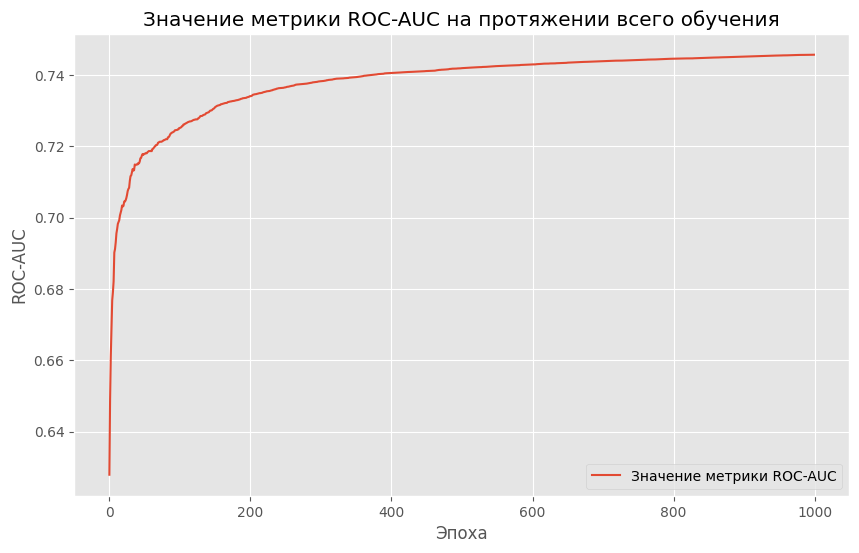

In [90]:
eval_result = model.get_evals_result()
val_auc_history = eval_result['validation']['AUC']

plt.figure(figsize=(10, 6))
sns.lineplot(data = val_auc_history, color='C0', label='Значение метрики ROC-AUC')
plt.legend(loc='lower right')
plt.title('Значение метрики ROC-AUC на протяжении всего обучения')
plt.xlabel('Эпоха')
plt.ylabel('ROC-AUC')
plt.show()

In [91]:
import pandas as pd
from pathlib import Path
from src.EDA.data_preprocessing import data_preprocessing, extract_features
from src.schema import category_cols, binary_cols

BASE_DIR = Path.cwd().parent
test_data_path = BASE_DIR / "datasets" / "train_data" / "train_data_11.pq"  # в качестве test dataset используем оставленный 11 датасет
target_data_path = BASE_DIR / "datasets" / "train_target.csv"

df_test = pd.read_parquet(test_data_path)
df_test = data_preprocessing(df_test, category_cols=category_cols, binary_cols=binary_cols)
df_test = extract_features(df_test, category_cols=category_cols, binary_cols=binary_cols)
df_target = pd.read_csv(target_data_path)
df_test = df_test.merge(df_target, on='id', how='left').set_index('id')

In [92]:
from catboost import Pool

X_test = df_test[model.feature_names_].copy()

cat_indices = model.get_cat_feature_indices()
cat_in_model = set(model.feature_names_[i] for i in cat_indices)

for col in X_test.select_dtypes(include=['category']).columns:
    if col not in cat_in_model:
        X_test[col] = X_test[col].astype(float)

test_pool = Pool(
    data=X_test,
    label=df_test['flag'] if 'flag' in df_test.columns else None,
    cat_features=cat_indices
)

pred = model.predict_proba(test_pool)

In [93]:
print(model.classes_)

[0 1]


В pred есть 2 колонки: принадлежность к классам model.classes_[0] и model.classes_[1], а надо искать вероятность принадлежности к классу 1, поэтому передаем pred[:, 1]

In [94]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

roc_auc = roc_auc_score(df_test['flag'], pred[:, 1]) # Возвращает вероятность того, что клиент уйдет в дефолт (т.е. вероятность класса 1)
print(f"ROC-AUC на тестовом датасете: {roc_auc:.4f}")

precision, recall, _ = precision_recall_curve(df_test['flag'], pred[:, 1])
pr_auc_score = auc(recall, precision)
print(f"Precision-Recall AUC на тестовом датасете: {pr_auc_score:.4f}")

ROC-AUC на тестовом датасете: 0.7172
Precision-Recall AUC на тестовом датасете: 0.0823


In [95]:
baseline_pr_auc = df_test['flag'].mean()
print(f"Базовый (случайный) PR-AUC: {baseline_pr_auc:.4f}")
print(f"Прирост модели: {pr_auc_score / baseline_pr_auc:.2f}x")

Базовый (случайный) PR-AUC: 0.0319
Прирост модели: 2.58x


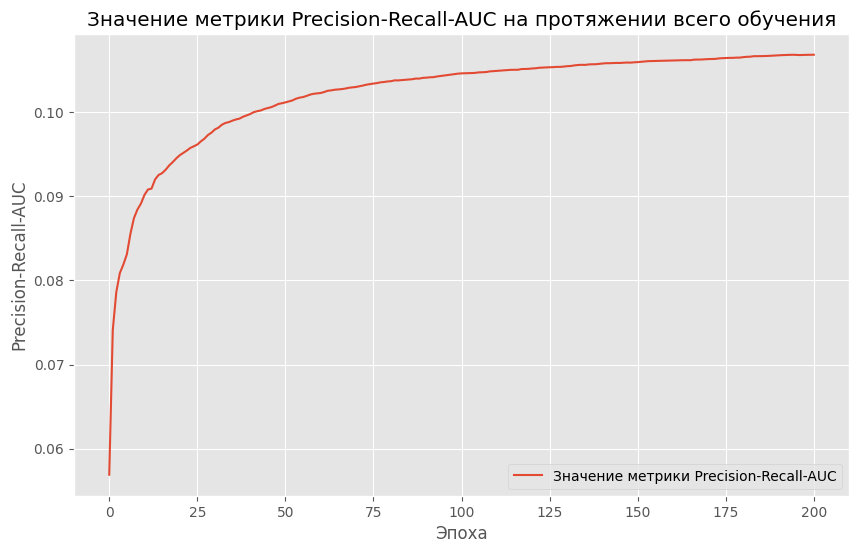

In [96]:
pr_auc_history = eval_result['validation']['PRAUC']

plt.figure(figsize=(10, 6))
sns.lineplot(data = pr_auc_history, color='C0', label='Значение метрики Precision-Recall-AUC')
plt.legend(loc='lower right')
plt.title('Значение метрики Precision-Recall-AUC на протяжении всего обучения')
plt.xlabel('Эпоха')
plt.ylabel('Precision-Recall-AUC')
plt.show()

Теперь с помощью метрики $F_{\beta}$-score вычислим оптимальный порог для вероятности клиентов

In [97]:
from sklearn.metrics import precision_score, recall_score
from tqdm import tqdm

thresholds = np.arange(0.0, 0.101, 0.001) # Берем пороги от 0 до 0.1 с шагом 0.001, так как в нашем случае вероятность дефолта низкая, и мы хотим поймать как можно больше дефолтов

beta = 2  # задаем значение beta для F-beta score
history_th, history_f_beta = [], []

for th in tqdm(thresholds):
    pred_th = (model.predict_proba(test_pool)[:, 1] >= th).astype(int)
    p, r = precision_score(df_test['flag'], pred_th), recall_score(df_test['flag'], pred_th)
    f_beta = (1 + beta ** 2) * (p * r) / ((beta ** 2 * p) + r)
    history_th.append(th)
    history_f_beta.append(f_beta)

100%|██████████| 101/101 [00:14<00:00,  7.11it/s]


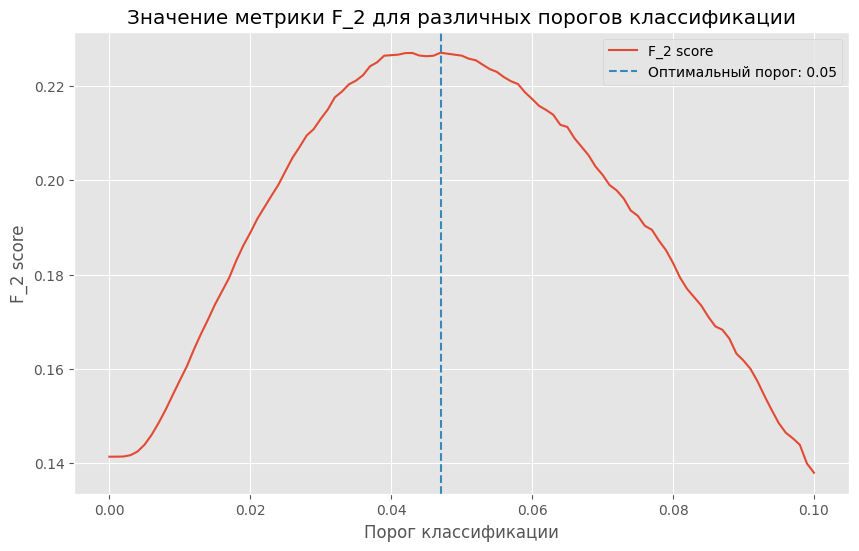

In [98]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=history_th, y=history_f_beta, color='C0', label=f'F_{beta} score')

max_index = np.argmax(history_f_beta)
max_threshold = history_th[max_index]
plt.axvline(x=max_threshold, color='C1', linestyle='--', label=f'Оптимальный порог: {max_threshold:.2f}') 

plt.legend()
plt.title(f'Значение метрики F_{beta} для различных порогов классификации')    
plt.xlabel('Порог классификации')
plt.ylabel(f'F_{beta} score')   
plt.show()  

In [99]:
from sklearn.metrics import confusion_matrix

pred = (model.predict_proba(test_pool)[:, 1] >= max_threshold).astype(int)
cm = confusion_matrix(df_test['flag'], pred)
display(pd.DataFrame(cm, index=['True Neg', 'True Pos'], columns=['Pred Neg', 'Pred Pos']))

,Pred Neg,Pred Pos
True Neg,194175,47852
True Pos,4180,3793


In [100]:
from sklearn.metrics import precision_score, recall_score
p, r = precision_score(df_test['flag'], pred), recall_score(df_test['flag'], pred)
print(f"Precision: {p:.4f}")    
print(f"Recall: {r:.4f}")

Precision: 0.0734
Recall: 0.4757


In [101]:
lgd, margin = 0.75, 0.12 # Задаем значения LGD и маржи для расчета прибыли (LGD - Loss Given Default, маржа - доходность по кредиту)

df_lim = df_test[['pre_loans_credit_limit_max', 'flag']].copy()
df_lim['pre_loans_credit_limit_max'] = df_lim['pre_loans_credit_limit_max'] + 1 # чтобы учитывать тех, у кого кредитный лимит равен 0, добавляем 1 к кредитному лимиту

mask = df_lim['flag'] == 1
df_lim.loc[mask, 'pre_loans_credit_limit_max'] *= -lgd
df_lim.loc[~mask, 'pre_loans_credit_limit_max'] *= margin

pred_class = (pred > max_threshold).astype(int)
df_lim['pred'] = pred_class

sum_base = df_lim['pre_loans_credit_limit_max'].sum() # Наивная модель - берем все кредиты, не делаем предсказаний
sum_profit = df_lim.loc[df_lim['pred'] == 0, 'pre_loans_credit_limit_max'].sum() # Модель - берем только те кредиты, которые модель предсказала как не дефолтные

print(f"Суммарная прибыль наивной модели: {sum_base:.2f}")
print(f"Суммарная прибыль по одобренным кредитам: {sum_profit:.2f}")
print(f"Прирост прибыли по сравнению с наивной моделью: {sum_profit / sum_base:.2f}x")

Суммарная прибыль наивной модели: 399011.79
Суммарная прибыль по одобренным кредитам: 349182.00
Прирост прибыли по сравнению с наивной моделью: 0.88x


Как мы видим, подбор threshold по максимизации $F_{2}$-score не дал хорошего результата, при заданных параметрах Margin и LGD найдем максимальную прибыль

In [102]:
def count_profit(df, pred, th):
    df_lim = df[['pre_loans_credit_limit_max', 'flag']].copy()
    df_lim['pre_loans_credit_limit_max'] = df_lim['pre_loans_credit_limit_max'] + 1

    mask = df_lim['flag'] == 1
    df_lim.loc[mask, 'pre_loans_credit_limit_max'] *= -lgd
    df_lim.loc[~mask, 'pre_loans_credit_limit_max'] *= margin

    pred_class = (pred > th).astype(int)
    df_lim['pred'] = pred_class

    sum_profit = df_lim.loc[df_lim['pred'] == 0, 'pre_loans_credit_limit_max'].sum()

    return sum_profit

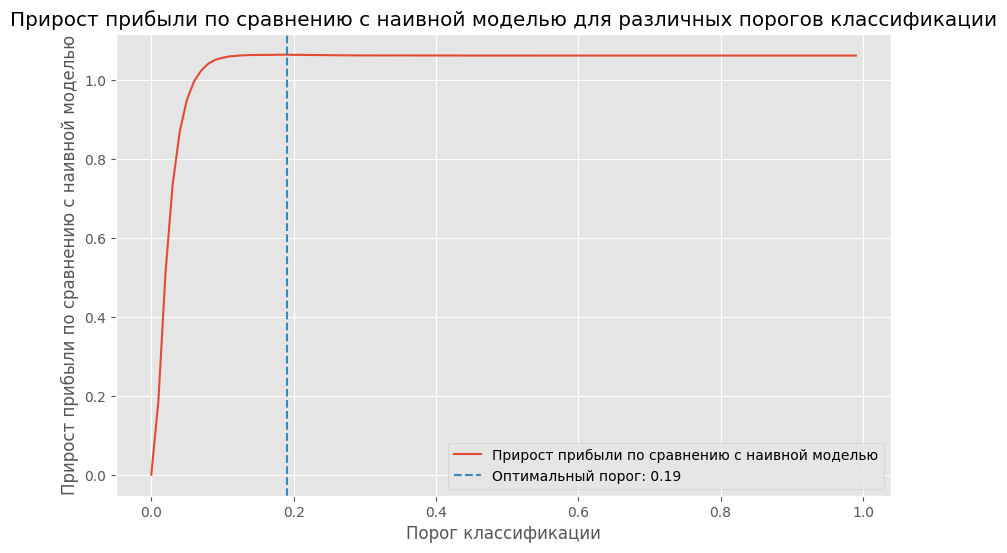

In [103]:
import warnings
warnings.filterwarnings("ignore")

history_profit = []
sum_base = df_test.loc[df_test['flag'] == 0, 'pre_loans_credit_limit_max'].sum() * margin - df_test.loc[df_test['flag'] == 1, 'pre_loans_credit_limit_max'].sum() * lgd
thresholds = np.arange(0.0, 1, 0.01)

for th in thresholds:
    pred_th = (model.predict_proba(test_pool)[:, 1] >= th).astype(int)
    sum_profit = count_profit(df_test, pred_th, th)
    history_profit.append(sum_profit / sum_base)

plt.figure(figsize=(10, 6))
sns.lineplot(x=thresholds, y=history_profit, color='C0', label='Прирост прибыли по сравнению с наивной моделью')

max_index = np.argmax(history_profit)
max_threshold = thresholds[max_index]
plt.axvline(x=max_threshold, color='C1', linestyle='--', label=f'Оптимальный порог: {max_threshold:.2f}') 
plt.legend()
plt.title('Прирост прибыли по сравнению с наивной моделью для различных порогов классификации')
plt.xlabel('Порог классификации')   
plt.ylabel('Прирост прибыли по сравнению с наивной моделью')
plt.show()

In [106]:
pred_th_max = (model.predict_proba(test_pool)[:, 1] >= max_threshold).astype(int)
profit_max = count_profit(df_test, pred_th_max, max_threshold)
print(f"Максимальный прирост прибыли по сравнению с наивной моделью: {profit_max / sum_base:.4f}x")

Максимальный прирост прибыли по сравнению с наивной моделью: 1.0635x
